# ML vs. GBERT: Held-Out Test Comparison

Run this opening section independently of the saved-artifact evaluation below. It predicts the complete canonical test split locally with a dev-selected TF-IDF model and the saved direct GBERT cascade. It reads reflection text in memory but never displays it, sends it to a provider, or enables tracing.

Use a trusted model saved by `00_segment_classification_ml.ipynb`, or explicitly enable dev-only ML selection here. No training or tuning uses test labels. Scope, gold-in-scope skill diagnostics, and end-to-end `N/0/1/2/3` tasks use one shared scorer and identical candidate rows. Zero-support classes remain visible; fixed-label macro-F1 and gold-supported macro-F1 are reported separately.

The existing GBERT checkpoint metadata does not contain training-split fingerprints. Matching the current training export cannot be certified from those artifacts alone. Report this limitation if splits changed since GBERT training. Timing includes local GBERT head loading, excludes tokenizer/model initialization, and is not a warmed-throughput benchmark.

In [1]:
from pathlib import Path
from itertools import product
from time import perf_counter
import os

import pandas as pd
from dotenv import load_dotenv
from IPython.display import display

from reflection_assessment_feedback.experiment_config import load_experiment_config
from reflection_assessment_feedback.segment_classification_ml import MLSettings, SegmentClassifierML
from reflection_assessment_feedback.segment_model_comparison import GBERTPredictor, compare_models

COMPARISON_ROOT = Path.cwd().resolve()
assert (COMPARISON_ROOT / 'config' / 'experiment.toml').is_file(), 'Run from the project root.'
load_dotenv(COMPARISON_ROOT / '.env', override=False)
COMPARISON_CONFIG = load_experiment_config()
COMPARISON_SPLIT_DIR = COMPARISON_ROOT / COMPARISON_CONFIG['paths']['provisional_split_directory']
GBERT_CHECKPOINT_DIR = COMPARISON_ROOT / COMPARISON_CONFIG['paths']['classifier_checkpoints']

RUN_MODEL_COMPARISON = False
SELECT_ML_ON_DEV = False
ML_MODEL_PATH = os.getenv('PREBI_ML_MODEL_PATH') or None
GBERT_DEVICE = 'cpu'
SAVE_COMPARISON = False

comparison_result = None
comparison_ml_model = None
ml_dev_comparison = []
print('Comparison ready. Choose a trusted ML_MODEL_PATH or enable SELECT_ML_ON_DEV.')
print('Set RUN_MODEL_COMPARISON=True to predict the complete test split; no provider calls.')

Comparison ready. Choose a trusted ML_MODEL_PATH or enable SELECT_ML_ON_DEV.
Set RUN_MODEL_COMPARISON=True to predict the complete test split; no provider calls.


In [6]:
import hashlib
import warnings

if RUN_MODEL_COMPARISON:
    comparison_splits = {
        split: pd.read_csv(
            COMPARISON_SPLIT_DIR / f'provisional_{split}_modeling_wide.csv',
            dtype={'candidate_id': str, 'segment_id': str, 'document_id': str, 'author_id': str},
        )
        for split in ('train', 'dev', 'test')
    }
    for left, right in [('train', 'dev'), ('train', 'test'), ('dev', 'test')]:
        for column in ('author_id', 'document_id', 'segment_id'):
            if set(comparison_splits[left][column]) & set(comparison_splits[right][column]):
                raise ValueError(f'{column} leakage between {left} and {right}.')
    if ML_MODEL_PATH is not None and SELECT_ML_ON_DEV:
        raise ValueError('Choose either a saved ML model or dev selection, not both.')
    if ML_MODEL_PATH is not None:
        comparison_ml_model = SegmentClassifierML.load(Path(ML_MODEL_PATH).expanduser())
        training_hashes = comparison_ml_model.training_metadata.get('split_sha256')
        if training_hashes:
            for split in ('train', 'dev'):
                current_hash = hashlib.sha256(
                    (COMPARISON_SPLIT_DIR / f'provisional_{split}_modeling_wide.csv').read_bytes()
                ).hexdigest()
                if training_hashes.get(split) != current_hash:
                    raise ValueError('Saved ML model training/dev data differs from the current export.')
        else:
            warnings.warn('ML artifact has no train/dev fingerprints; verify provenance manually.')
    elif SELECT_ML_ON_DEV:
        best_comparison_dev_score = float('-inf')
        for architecture, estimator, regularization, class_weight in product(
            ('direct', 'hierarchical'), ('logistic', 'linear_svc'), (0.3, 1.0, 3.0), (None, 'balanced'),
        ):
            settings = MLSettings(
                architecture=architecture, estimator=estimator,
                regularization=regularization, class_weight=class_weight,
                seed=int(COMPARISON_CONFIG['classifier']['seed']),
            )
            candidate_model = SegmentClassifierML(settings).fit(comparison_splits['train'])
            dev_score = candidate_model.evaluate(comparison_splits['dev'])['selection_macro_f1']
            ml_dev_comparison.append({
                'architecture': architecture, 'estimator': estimator,
                'regularization': regularization, 'class_weight': class_weight,
                'dev_macro_f1': dev_score,
            })
            if dev_score > best_comparison_dev_score:
                best_comparison_dev_score = dev_score
                comparison_ml_model = candidate_model
        display(pd.DataFrame(ml_dev_comparison).sort_values('dev_macro_f1', ascending=False))
    else:
        raise RuntimeError('Set ML_MODEL_PATH or SELECT_ML_ON_DEV=True before comparison.')
    assert comparison_ml_model is not None
    print('Frozen ML settings:', comparison_ml_model.settings)
    warnings.warn('GBERT checkpoints lack training-split hashes; verify their training export before interpreting results.')
    initialization_started = perf_counter()
    comparison_gbert_model = GBERTPredictor(
        GBERT_CHECKPOINT_DIR, COMPARISON_CONFIG['classifier'], device=GBERT_DEVICE,
    )
    gbert_initialization_seconds = perf_counter() - initialization_started
    comparison_result = compare_models(
        comparison_splits['test'], {'ML': comparison_ml_model, 'GBERT': comparison_gbert_model},
    )
    print(f'Compared {comparison_result["candidate_rows"]} candidate rows, '
          f'{comparison_result["unique_segments"]} unique segments, '
          f'{comparison_result["documents"]} test documents. Text and identifiers withheld.')
    print(f'GBERT tokenizer/config initialization: {gbert_initialization_seconds:.2f}s; device={GBERT_DEVICE}.')
else:
    print('Model comparison disabled. Enable RUN_MODEL_COMPARISON in the setup cell.')

,architecture,estimator,regularization,class_weight,dev_macro_f1
13,hierarchical,logistic,0.3,balanced,0.554475
17,hierarchical,logistic,3.0,balanced,0.552305
5,direct,logistic,3.0,balanced,0.551511
19,hierarchical,linear_svc,0.3,balanced,0.550649
3,direct,logistic,1.0,balanced,0.548097
21,hierarchical,linear_svc,1.0,balanced,0.546921
7,direct,linear_svc,0.3,balanced,0.546033
15,hierarchical,logistic,1.0,balanced,0.543505
9,direct,linear_svc,1.0,balanced,0.540570
1,direct,logistic,0.3,balanced,0.535606


Frozen ML settings: MLSettings(architecture='hierarchical', estimator='logistic', regularization=0.3, class_weight='balanced', minimum_text_characters=10, word_max_features=40000, char_max_features=60000, seed=20260929)


/var/folders/13/2n2gvz0n6vvc64bn7jh4fpx40000gp/T/ipykernel_12649/38733890.py:55: UserWarning: GBERT checkpoints lack training-split hashes; verify their training export before interpreting results.
  warnings.warn('GBERT checkpoints lack training-split hashes; verify their training export before interpreting results.')
/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Compared 905 candidate rows, 903 unique segments, 24 test documents. Text and identifiers withheld.
GBERT tokenizer/config initialization: 1.82s; device=mps.


accuracy         macro_f1         supported_macro_f1          \
model            GBERT      ML    GBERT      ML              GBERT      ML   
task                                                                         
HA_end_to_end   0.8994  0.8530   0.5623  0.5049             0.5623  0.5049   
HA_gold_scope   0.9199  0.8879   0.5564  0.5064             0.5564  0.5064   
SW_end_to_end   0.7967  0.7127   0.5522  0.4863             0.6902  0.6079   
SW_gold_scope   0.8112  0.7368   0.5452  0.4859             0.7269  0.6479   
UA_end_to_end   0.7238  0.6818   0.6702  0.6205             0.6702  0.6205   
UA_gold_scope   0.7368  0.7002   0.6914  0.6518             0.6914  0.6518   
scope           0.9768  0.9591   0.7959  0.7551             0.7959  0.7551   

              weighted_f1              n         
model               GBERT      ML  GBERT     ML  
task                                             
HA_end_to_end      0.8945  0.8566  905.0  905.0  
HA_gold_scope      0.9164  0.8872  874.0  874.0  
SW_end_to_end      0.7917  0.7207  905.0  905.0  
SW_gold_scope      0.8073  0.7443  874.0  874.0  
UA_end_to_end      0.7184  0.6811  905.0  905.0  
UA_gold_scope      0.7317  0.6996  874.0  874.0  
scope              0.9749  0.9633  905.0  905.0

Fixed-label macro-F1 difference; positive means GBERT is higher:


model,GBERT,ML,GBERT_minus_ML
task,,,
HA_end_to_end,0.5623,0.5049,0.0574
HA_gold_scope,0.5564,0.5064,0.0500
SW_end_to_end,0.5522,0.4863,0.0659
SW_gold_scope,0.5452,0.4859,0.0592
UA_end_to_end,0.6702,0.6205,0.0497
UA_gold_scope,0.6914,0.6518,0.0396
scope,0.7959,0.7551,0.0408


Per-class results: support=0 means this test split cannot measure that class recall.


,task,class,precision,recall,f1,support,model
0,scope,0,0.4375,0.6774,0.5316,31,ML
1,scope,1,0.9883,0.9691,0.9786,874,ML
2,SW_gold_scope,0,0.8506,0.7708,0.8087,480,ML
3,SW_gold_scope,1,0.7152,0.7516,0.7329,314,ML
4,SW_gold_scope,2,0.3486,0.4750,0.4021,80,ML
5,SW_gold_scope,3,0.0000,0.0000,0.0000,0,ML
6,SW_end_to_end,N,0.4375,0.6774,0.5316,31,ML
7,SW_end_to_end,0,0.8345,0.7458,0.7877,480,ML
8,SW_end_to_end,1,0.7099,0.7325,0.7210,314,ML
9,SW_end_to_end,2,0.3462,0.4500,0.3913,80,ML


Local timing includes GBERT head loading; this is not warmed model throughput.


,model,end_to_end_seconds,gold_scope_diagnostic_seconds,milliseconds_per_candidate
0,ML,0.084,0.074,0.093
1,GBERT,10.647,7.650,11.765


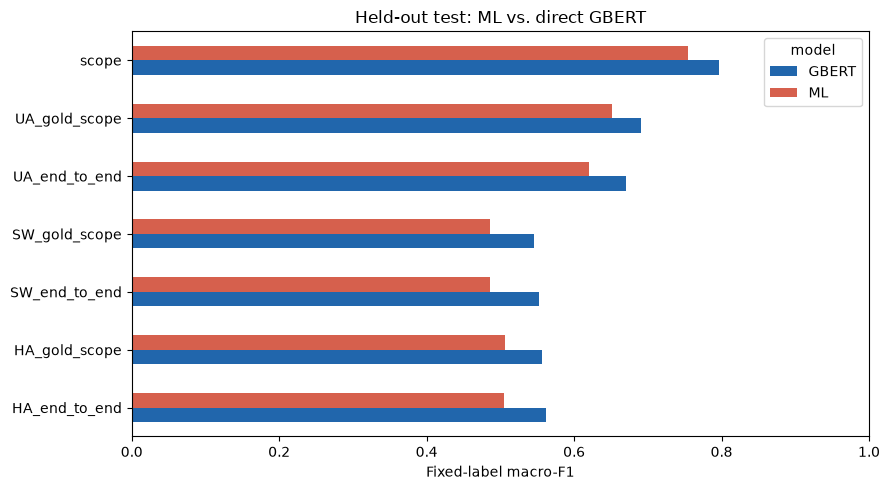

In [7]:
import matplotlib.pyplot as plt

if comparison_result is not None:
    comparison_summary = comparison_result['summary']
    display(comparison_summary.pivot(
        index='task', columns='model', values=['accuracy', 'macro_f1', 'supported_macro_f1', 'weighted_f1', 'n'],
    ).round(4))
    f1_comparison = comparison_summary.pivot(index='task', columns='model', values='macro_f1')
    f1_comparison['GBERT_minus_ML'] = f1_comparison['GBERT'] - f1_comparison['ML']
    print('Fixed-label macro-F1 difference; positive means GBERT is higher:')
    display(f1_comparison.round(4))
    print('Per-class results: support=0 means this test split cannot measure that class recall.')
    display(comparison_result['per_class'].round(4))
    print('Local timing includes GBERT head loading; this is not warmed model throughput.')
    display(comparison_result['timings'].round(3))
    plot_table = comparison_summary.pivot(index='task', columns='model', values='macro_f1')
    axis = plot_table.plot.barh(figsize=(9, 5), color=['#2166ac', '#d6604d'], xlim=(0, 1))
    axis.set_xlabel('Fixed-label macro-F1')
    axis.set_ylabel('')
    axis.set_title('Held-out test: ML vs. direct GBERT')
    plt.tight_layout()
    plt.show()
else:
    print('Run the comparison cell before displaying results.')

In [4]:
import json
from dataclasses import asdict
from datetime import datetime, timezone

if SAVE_COMPARISON:
    if comparison_result is None or comparison_ml_model is None:
        raise RuntimeError('Run the comparison before exporting aggregate metrics.')
    protected_value = os.getenv('PREBI_DATA_ROOT')
    if not protected_value:
        raise RuntimeError('Set PREBI_DATA_ROOT to approved protected storage.')
    comparison_protected_root = Path(protected_value).expanduser().resolve()
    if comparison_protected_root == COMPARISON_ROOT or COMPARISON_ROOT in comparison_protected_root.parents:
        raise ValueError('Protected storage must be outside the source tree.')
    comparison_directory = comparison_protected_root / 'evaluation' / (
        'ml-vs-gbert-' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
    )
    comparison_directory.mkdir(parents=True, mode=0o700, exist_ok=False)
    for name in ('summary', 'per_class', 'timings'):
        destination = comparison_directory / f'{name}.csv'
        comparison_result[name].to_csv(destination, index=False)
        os.chmod(destination, 0o600)
    checkpoint_hashes = {}
    for name, path in comparison_gbert_model.checkpoints.items():
        with path.open('rb') as checkpoint_file:
            checkpoint_hashes[name] = hashlib.file_digest(checkpoint_file, 'sha256').hexdigest()
    provenance = {
        'split': 'test', 'candidate_rows': comparison_result['candidate_rows'],
        'unique_segments': int(comparison_result['unique_segments']),
        'documents': int(comparison_result['documents']),
        'ml_settings': asdict(comparison_ml_model.settings),
        'ml_dev_comparison': ml_dev_comparison,
        'gbert_settings': COMPARISON_CONFIG['classifier'], 'gbert_device': GBERT_DEVICE,
        'gbert_checkpoint_sha256': checkpoint_hashes,
        'gbert_training_split_provenance': 'Unavailable in existing checkpoint metadata',
        'timing_policy': 'Head loading included; initialization and gold-scope diagnostic reported separately',
        'split_sha256': {
            split: hashlib.sha256(
                (COMPARISON_SPLIT_DIR / f'provisional_{split}_modeling_wide.csv').read_bytes()
            ).hexdigest() for split in ('train', 'dev', 'test')
        },
    }
    if ML_MODEL_PATH is not None:
        with Path(ML_MODEL_PATH).expanduser().open('rb') as model_file:
            provenance['ml_model_sha256'] = hashlib.file_digest(model_file, 'sha256').hexdigest()
    metadata_path = comparison_directory / 'provenance.json'
    with metadata_path.open('x', encoding='utf-8') as metadata_file:
        json.dump(provenance, metadata_file, indent=2)
    os.chmod(metadata_path, 0o600)
    print('Aggregate comparison exported to approved protected storage; path withheld.')
else:
    print('Comparison export disabled. The artifact-only workflow below is independent.')

Comparison export disabled. The artifact-only workflow below is independent.


# Segment Classifier Evaluation

Evaluate saved scope and component-band predictions against the held-out provisional test labels. In this project, a *segment* is a reflection-text unit, not an image mask. This notebook adapts the usual segmentation-evaluation stages to categorical segment classification; it never loads reflection text, calls a model provider, or enables tracing.

The default evaluation requires predictions for every test document. A document subset is a pilot only and must not be reported as final test performance. Gold labels are candidate-grain: multiple candidate annotation bundles for one segment remain separate rows and are never merged or averaged. Prediction artifacts are one-per-segment and are joined to each gold candidate by document and segment IDs.

Artifacts and data are controlled research data. Keep them in approved protected storage, do not publish identifiers or row-level results, and do not use held-out test results for model or threshold tuning. Artifacts contain categorical predictions only, so probability-based metrics and threshold sweeps are unavailable.

## 1. Set Up Environment and Imports

Run from the `prebi_v1` project root using its `.venv` kernel. Paths and switches are centralized here. Export is aggregate-only and disabled unless explicitly enabled after review.

In [ ]:
import json
import os
import warnings
from pathlib import Path
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

from reflection_assessment_feedback import IntermediateAnalysis
from reflection_assessment_feedback.experiment_config import load_experiment_config

PROJECT_ROOT = Path.cwd().resolve()
assert PROJECT_ROOT.name == "prebi_v1", "Run this notebook from the prebi_v1 project root."
EXPERIMENT_CONFIG = load_experiment_config()
DATASET_CONFIG = EXPERIMENT_CONFIG["dataset"]
LABEL_CONFIG = EXPERIMENT_CONFIG["labels"]
EVALUATION_CONFIG = EXPERIMENT_CONFIG["evaluation"]
GOLD_PATH = (
    PROJECT_ROOT
    / EXPERIMENT_CONFIG["paths"]["provisional_split_directory"]
    / f"provisional_{DATASET_CONFIG['prediction_split']}_modeling_wide.csv"
)
PROTECTED_ROOT_VALUE = os.getenv("PREBI_DATA_ROOT")

# None evaluates the complete test split. A list is for pilot inspection only.
PILOT_DOCUMENT_IDS = None
SAVE_METRICS = EVALUATION_CONFIG["save_metrics"]
RANDOM_SEED = EVALUATION_CONFIG["random_seed"]

DIMENSIONS = LABEL_CONFIG["skill_dimensions"]
SCOPE_CLASS_IDS = LABEL_CONFIG["class_ids"]["scope"]
SCOPE_LABELS = [label_id for _, label_id in sorted(SCOPE_CLASS_IDS.items(), key=lambda item: item[1])]
SCOPE_NAMES = [name for name, _ in sorted(SCOPE_CLASS_IDS.items(), key=lambda item: item[1])]
BAND_NAMES = LABEL_CONFIG["class_ids"]["components"]["bands"]
BAND_LABELS = [int(label) for label in BAND_NAMES]
END_TO_END_NAMES = LABEL_CONFIG["class_ids"]["components"]["end_to_end"]
END_TO_END_LABELS = list(range(len(END_TO_END_NAMES)))

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (7, 5)

if not GOLD_PATH.is_file():
    raise FileNotFoundError("Canonical test modeling split was not found.")
if not PROTECTED_ROOT_VALUE:
    raise RuntimeError("Set PREBI_DATA_ROOT to the approved protected data directory.")
PROTECTED_ROOT = Path(PROTECTED_ROOT_VALUE).expanduser().resolve()
if PROTECTED_ROOT == PROJECT_ROOT or PROJECT_ROOT in PROTECTED_ROOT.parents:
    raise ValueError("PREBI_DATA_ROOT must be outside the project source tree.")
PREDICTION_DIR = PROTECTED_ROOT / "g2" / "predictions"
print("Evaluation configuration loaded; protected paths are withheld.")

Evaluation paths validated; protected paths are withheld.


## 2. Load Ground Truth and Predicted Segments

Read only candidate/document/segment IDs and target columns from the held-out modeling view. Load one validated predicted-analysis artifact per document. The join retains every candidate bundle; no text or annotation metadata is loaded.

In [4]:
gold_columns = [
    "candidate_id",
    "document_id",
    "segment_id",
    "scope_target",
    *(f"target_{dimension}" for dimension in DIMENSIONS),
]
gold = pd.read_csv(GOLD_PATH, usecols=gold_columns, dtype={"document_id": str, "segment_id": str})
if gold[["candidate_id", "document_id", "segment_id", "scope_target"]].isna().any().any():
    raise ValueError("Gold evaluation view contains missing IDs or scope labels.")
gold["candidate_id"] = gold["candidate_id"].astype(str)
gold["scope_target"] = pd.to_numeric(gold["scope_target"], errors="raise").astype(int)

if PILOT_DOCUMENT_IDS is not None:
    pilot_ids = {str(document_id) for document_id in PILOT_DOCUMENT_IDS}
    gold = gold.loc[gold["document_id"].isin(pilot_ids)].copy()
    if gold.empty or set(gold["document_id"]) != pilot_ids:
        raise ValueError("Pilot selection includes a missing or non-test document.")
    warnings.warn("PILOT ONLY: this subset is not final test-set evaluation.", stacklevel=1)

document_ids = sorted(gold["document_id"].unique())
prediction_rows = []
for document_id in document_ids:
    artifact_path = PREDICTION_DIR / f"predicted-analysis-{quote(document_id, safe='')}.json"
    if not artifact_path.is_file():
        raise FileNotFoundError("A selected test document has no prediction artifact.")
    package = json.loads(artifact_path.read_text(encoding="utf-8"))
    if package.get("document_id") != document_id:
        raise ValueError("Prediction artifact document ID does not match its selected document.")
    analysis = IntermediateAnalysis.model_validate(package.get("analysis", {}))
    if analysis.source != "predicted":
        raise ValueError("Evaluation requires predicted analysis, not human annotations.")
    if len({segment.segment_id for segment in analysis.segments}) != len(analysis.segments):
        raise ValueError("Prediction artifact contains duplicate segment IDs.")
    for segment in analysis.segments:
        prediction_rows.append({
            "document_id": document_id,
            "segment_id": segment.segment_id,
            "predicted_scope": 1 if segment.scope == "in_scope" else 0,
            **{
                f"predicted_{dimension}": (
                    int(segment.component_bands[dimension_code])
                    if segment.scope == "in_scope"
                    else -1
                )
                for dimension, dimension_code in DIMENSIONS.items()
            },
        })

predictions = pd.DataFrame(prediction_rows)
if predictions.duplicated(["document_id", "segment_id"]).any():
    raise ValueError("Predictions are not unique by document and segment.")
print(f"Loaded protected labels and predictions for {len(document_ids)} documents; row details withheld.")

Loaded protected labels and predictions for 1 documents; row details withheld.


/var/folders/13/2n2gvz0n6vvc64bn7jh4fpx40000gp/T/ipykernel_8824/4149477101.py:19: UserWarning: PILOT ONLY: this subset is not final test-set evaluation.
  warnings.warn("PILOT ONLY: this subset is not final test-set evaluation.", stacklevel=1)


## 3. Validate Shapes, Labels, and Data Types

Here, “shape” means candidate and segment coverage. The canonical view intentionally has repeated segment IDs for alternative candidate labels, while the model artifact must have one prediction per segment. Out-of-scope candidate skill targets are not applicable and are excluded from conditional skill scoring.

In [5]:
if gold[["candidate_id", "document_id", "segment_id", "scope_target"]].isna().any().any():
    raise ValueError("Gold evaluation view contains missing IDs or scope labels.")
if gold["candidate_id"].duplicated().any():
    raise ValueError("Candidate IDs must uniquely identify gold annotation bundles.")
if not gold["scope_target"].isin([0, 1]).all():
    raise ValueError("Scope labels must be encoded as 0 or 1.")

in_scope_gold = gold["scope_target"] == 1
for dimension in DIMENSIONS:
    target_column = f"target_{dimension}"
    if gold.loc[in_scope_gold, target_column].isna().any():
        raise ValueError("An in-scope gold candidate has a missing component label.")
    valid_targets = pd.to_numeric(gold.loc[in_scope_gold, target_column], errors="raise")
    if not valid_targets.isin(BAND_LABELS).all():
        raise ValueError("Component gold labels must use integer classes 0 through 3.")
    gold.loc[in_scope_gold, target_column] = valid_targets.astype(int)

if gold.empty or predictions.empty:
    raise ValueError("There are no selected gold candidates or prediction segments.")
gold_segment_keys = set(zip(gold["document_id"], gold["segment_id"], strict=True))
prediction_segment_keys = set(zip(predictions["document_id"], predictions["segment_id"], strict=True))
if gold_segment_keys != prediction_segment_keys:
    raise ValueError("Prediction segment coverage differs from the selected gold documents.")

evaluation = gold.merge(
    predictions,
    on=["document_id", "segment_id"],
    how="left",
    validate="many_to_one",
    indicator=True,
)
if not evaluation["_merge"].eq("both").all():
    raise ValueError("Some candidate gold rows did not receive a segment prediction.")
evaluation = evaluation.drop(columns="_merge")
print(
    f"Validated {len(evaluation)} candidate rows across "
    f"{evaluation['segment_id'].nunique()} unique segments; labels and IDs withheld."
)

Validated 37 candidate rows across 37 unique segments; labels and IDs withheld.


## 4. Compute Pixel-Level Confusion Components

The analogous unit here is the candidate-segment label, not a pixel. One-vs-rest true/false positives and negatives are represented by per-class confusion matrices for each categorical task. The next section reports these matrices and standard classification metrics.

## 5. Implement Core Segmentation Metrics

For categorical labels, report accuracy, macro-F1, weighted-F1, and per-class precision, recall, F1, and support. Undefined class-specific scores use zero division; accuracy remains the exact fraction correct. Conditional component scores apply only to gold in-scope rows that the predicted scope routes in-scope. End-to-end scores include out-of-scope as `N`, so missed or spurious scope decisions count as component errors.

In [9]:
def score_task(task, gold_labels, predicted_labels, class_labels, class_names):
    gold_array = np.asarray(gold_labels, dtype=int)
    predicted_array = np.asarray(predicted_labels, dtype=int)
    if len(gold_array) == 0:
        return None, np.zeros((len(class_labels), len(class_labels)), dtype=int)
    if len(gold_array) != len(predicted_array):
        raise ValueError("Gold and predicted evaluation arrays must have equal lengths.")
    matrix = confusion_matrix(gold_array, predicted_array, labels=class_labels)
    precision, recall, f1, support = precision_recall_fscore_support(
        gold_array,
        predicted_array,
        labels=class_labels,
        zero_division=0,
    )
    total = int(support.sum())
    accuracy = float(np.trace(matrix) / total) if total else 0.0
    macro_f1 = float(f1.mean()) if len(f1) else 0.0
    weighted_f1 = float(np.average(f1, weights=support)) if total else 0.0
    rows = [{
        "task": task,
        "class": class_name,
        "precision": float(class_precision),
        "recall": float(class_recall),
        "f1": float(class_f1),
        "support": int(class_support),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "micro_f1": accuracy,
        "weighted_f1": weighted_f1,
        "n": total,
    } for class_name, class_precision, class_recall, class_f1, class_support in zip(
        class_names, precision, recall, f1, support, strict=True
    )]
    return rows, matrix


def add_task(task, gold_labels, predicted_labels, class_labels, class_names):
    rows, matrix = score_task(task, gold_labels, predicted_labels, class_labels, class_names)
    if rows is not None:
        metric_rows.extend(rows)
        confusion_matrices[task] = (matrix, class_names)


gold_scope = evaluation["scope_target"].to_numpy(dtype=int)
predicted_scope = evaluation["predicted_scope"].to_numpy(dtype=int)
metric_rows = []
confusion_matrices = {}
add_task("scope", gold_scope, predicted_scope, SCOPE_LABELS, SCOPE_NAMES)

for dimension in DIMENSIONS:
    gold_component = evaluation[f"target_{dimension}"].to_numpy(dtype=int, na_value=-9)
    predicted_component = evaluation[f"predicted_{dimension}"].to_numpy(dtype=int)
    eligible = gold_scope == 1
    routed = eligible & (predicted_scope == 1)
    add_task(
        f"{dimension}_conditional_routed",
        gold_component[routed],
        predicted_component[routed],
        BAND_LABELS,
        BAND_NAMES,
    )
    gold_end_to_end = np.where(eligible, gold_component + 1, 0)
    predicted_end_to_end = np.where(predicted_scope == 1, predicted_component + 1, 0)
    add_task(
        f"{dimension}_end_to_end",
        gold_end_to_end,
        predicted_end_to_end,
        END_TO_END_LABELS,
        END_TO_END_NAMES,
    )

component_coverage = []
for dimension in DIMENSIONS:
    eligible = gold_scope == 1
    routed = eligible & (predicted_scope == 1)
    component_coverage.append({
        "task": dimension,
        "gold_in_scope_candidates": int(eligible.sum()),
        "routed_to_component_model": int(routed.sum()),
        "routed_coverage": float(routed.sum() / eligible.sum()) if eligible.any() else 0.0,
    })

per_class_metrics = pd.DataFrame(metric_rows)
overall_metrics = per_class_metrics.drop_duplicates("task").loc[
    :, ["task", "accuracy", "macro_f1", "micro_f1", "weighted_f1", "n"]
].reset_index(drop=True)
coverage_metrics = pd.DataFrame(component_coverage)
print("Scoring complete; outputs contain aggregate metrics only.")

Scoring complete; outputs contain aggregate metrics only.


## 6. Run Per-Class and Per-Segment Evaluation

The tidy table is class-level aggregate output, not a row-level prediction dump. Each task has one row per class and task-level scores repeated for convenient filtering. Candidate-bundle rows are the independent labeled observations; segment and document identifiers are deliberately excluded from displayed tables.

In [7]:
# Aggregate candidate-row performance by document without retaining document IDs in the report.
document_scores = []
for _, document_rows in evaluation.groupby("document_id", sort=False):
    scope_score = score_task(
        "scope", document_rows["scope_target"], document_rows["predicted_scope"], SCOPE_LABELS, SCOPE_NAMES
    )[0]
    document_scores.append({"scope_macro_f1": scope_score[0]["macro_f1"]})

per_document_distribution = pd.DataFrame(document_scores).agg(["mean", "median"]).T
print("Per-document scope macro-F1 distribution (IDs withheld):")
display(per_document_distribution.round(3))

Per-document scope macro-F1 distribution (IDs withheld):


,mean,median
scope_macro_f1,0.5,0.5


## 7. Evaluate at Multiple Thresholds (Probabilistic Outputs)

The saved `IntermediateAnalysis` artifact stores only categorical scope and component labels; no probabilities or logits are persisted. A threshold sweep cannot be computed from these artifacts. This categorical routing summary reports how often gold in-scope candidates reach the component classifiers instead.

In [10]:
display(coverage_metrics.round(3))

,task,gold_in_scope_candidates,routed_to_component_model,routed_coverage
0,situationserfassung,37,37,1.0
1,analyse,37,37,1.0
2,konsequenzen,37,37,1.0


## 8. Visualize Masks, Overlays, and Error Maps

This classifier has no image masks. The privacy-safe equivalent is to plot aggregate score distributions and class-wise confusion matrices. No reflection text, examples, per-row errors, or document identifiers are rendered.

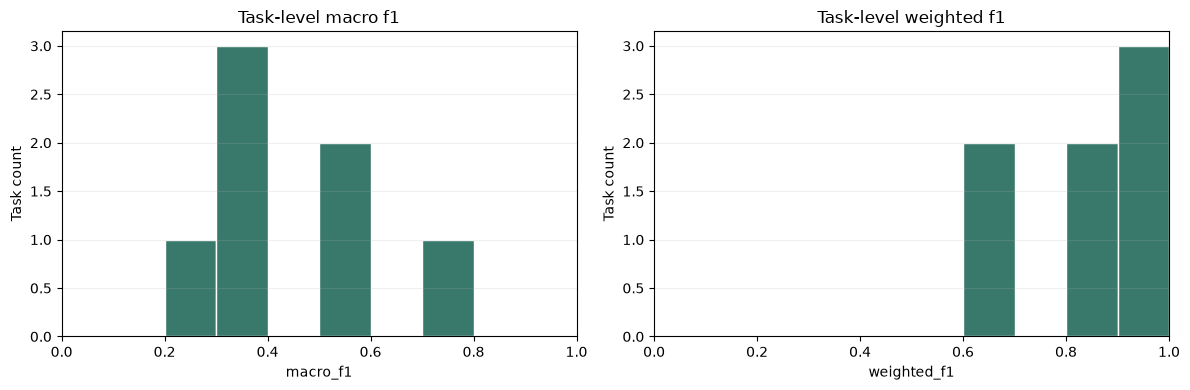

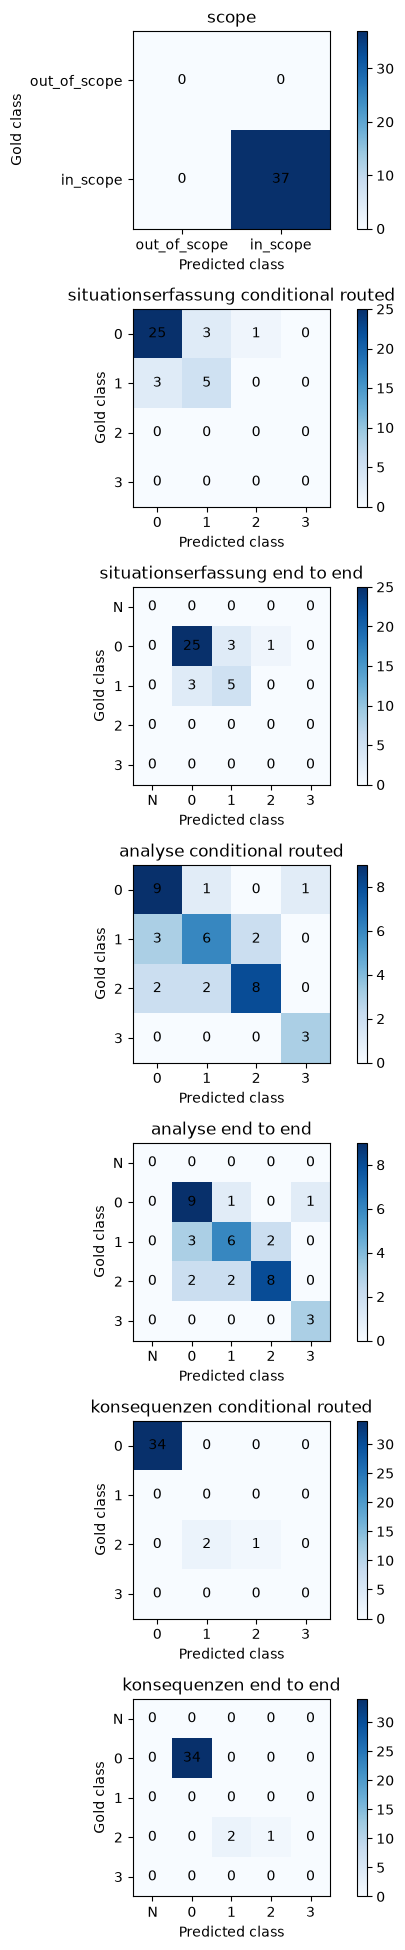

,task,accuracy,macro_f1,micro_f1,weighted_f1,n
0,scope,1.000,0.500,1.000,1.000,37
1,situationserfassung_conditional_routed,0.811,0.376,0.811,0.823,37
2,situationserfassung_end_to_end,0.811,0.300,0.811,0.823,37
3,analyse_conditional_routed,0.703,0.726,0.703,0.698,37
4,analyse_end_to_end,0.703,0.581,0.703,0.698,37
5,konsequenzen_conditional_routed,0.946,0.375,0.946,0.959,37
6,konsequenzen_end_to_end,0.946,0.300,0.946,0.959,37


,task,class,precision,recall,f1,support,accuracy,macro_f1,micro_f1,weighted_f1,n
12,analyse_conditional_routed,1,0.667,0.545,0.600,11,0.703,0.726,0.703,0.698,37
11,analyse_conditional_routed,0,0.643,0.818,0.720,11,0.703,0.726,0.703,0.698,37
13,analyse_conditional_routed,2,0.800,0.667,0.727,12,0.703,0.726,0.703,0.698,37
14,analyse_conditional_routed,3,0.750,1.000,0.857,3,0.703,0.726,0.703,0.698,37
15,analyse_end_to_end,N,0.000,0.000,0.000,0,0.703,0.581,0.703,0.698,37
17,analyse_end_to_end,1,0.667,0.545,0.600,11,0.703,0.581,0.703,0.698,37
16,analyse_end_to_end,0,0.643,0.818,0.720,11,0.703,0.581,0.703,0.698,37
18,analyse_end_to_end,2,0.800,0.667,0.727,12,0.703,0.581,0.703,0.698,37
19,analyse_end_to_end,3,0.750,1.000,0.857,3,0.703,0.581,0.703,0.698,37
21,konsequenzen_conditional_routed,1,0.000,0.000,0.000,0,0.946,0.375,0.946,0.959,37


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, metric_name in zip(axes, ("macro_f1", "weighted_f1"), strict=True):
    values = overall_metrics[metric_name].to_numpy(dtype=float)
    axis.hist(values, bins=np.linspace(0, 1, 11), color="#39796B", edgecolor="white")
    axis.set(title=f"Task-level {metric_name.replace('_', ' ')}", xlabel=metric_name, ylabel="Task count")
    axis.set_xlim(0, 1)
    axis.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

matrix_tasks = list(confusion_matrices)
fig, axes = plt.subplots(len(matrix_tasks), 1, figsize=(7, max(3, 2.8 * len(matrix_tasks))), squeeze=False)
for axis, task in zip(axes[:, 0], matrix_tasks, strict=True):
    matrix, class_names = confusion_matrices[task]
    image = axis.imshow(matrix, cmap="Blues")
    axis.set(
        title=task.replace("_", " "),
        xlabel="Predicted class",
        ylabel="Gold class",
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
    )
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            axis.text(column_index, row_index, str(matrix[row_index, column_index]), ha="center", va="center")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

display(overall_metrics.round(3))
display(per_class_metrics.sort_values(["task", "f1"], ascending=[True, True]).round(3))

## 9. Aggregate Results and Export Evaluation Report

Macro-F1 weights classes equally; weighted-F1 weights by candidate support; micro-F1 equals accuracy for these single-label tasks. Document-level summaries are aggregated across documents without retaining document IDs. Optional exports contain only task/class aggregates and coverage counts, are written beneath protected storage, and remain disabled by default.

In [ ]:
from reflection_assessment_feedback.experiment_config import experiment_config_sha256

summary_by_task = overall_metrics.set_index("task")[["accuracy", "macro_f1", "micro_f1", "weighted_f1", "n"]]
dataset_summary = summary_by_task.agg(["mean", "median"]).T
print("Across-task metric distribution:")
display(dataset_summary.round(3))

if SAVE_METRICS:
    evaluation_dir = PROTECTED_ROOT / "g2" / "evaluation"
    evaluation_dir.mkdir(parents=True, exist_ok=True, mode=0o700)
    per_class_metrics.to_csv(evaluation_dir / "segment-evaluation-per-class.csv", index=False)
    overall_metrics.to_csv(evaluation_dir / "segment-evaluation-overall.csv", index=False)
    coverage_metrics.to_csv(evaluation_dir / "segment-evaluation-coverage.csv", index=False)
    report = {
        "split": f"provisional_{DATASET_CONFIG['prediction_split']}",
        "pilot_only": PILOT_DOCUMENT_IDS is not None,
        "document_count": len(document_ids),
        "candidate_row_count": len(evaluation),
        "unique_segment_count": int(evaluation["segment_id"].nunique()),
        "experiment_config_sha256": experiment_config_sha256(),
        "overall_metrics": overall_metrics.to_dict(orient="records"),
        "coverage_metrics": coverage_metrics.to_dict(orient="records"),
        "probability_metrics_available": False,
    }
    with (evaluation_dir / "segment-evaluation-summary.json").open("w", encoding="utf-8") as report_file:
        json.dump(report, report_file, indent=2)
    print("Aggregate metrics exported under protected storage; output paths withheld.")
else:
    print("Metric export is disabled; no files were written.")

Across-task metric distribution:


,mean,median
accuracy,0.846,0.811
macro_f1,0.451,0.376
micro_f1,0.846,0.811
weighted_f1,0.851,0.823
n,37.000,37.000


Metric export is disabled; no files were written.
